# 📘 SISTEM BERBASIS PENGETAHUAN  
## BAB 7: CERTAINTY FACTOR  

### Studi Kasus: Rekomendasi Tempat Wisata Bali  

---

## 👤 Identitas Kelompok

| No | Nama | NIM | Kelas |
|----|------|------|-------|
| 1 |  | |  |
| 2 | DINI ELMININGTYAS RAHAYU WILUJENG | 2341760180 | D4 Sistem Informasi Bisnis |
| 3 |  |  |  |
| 4 |  |  |  |
| 5 | MUHAMMAD ULIL FAHMI MA'RIFATULLOH | 2341760194 | D4 Sistem Informasi Bisnis |


---

## 🎯 TUJUAN PRAKTIKUM

1. Memahami konsep Certainty Factor (CF)  
2. Memahami cara menghitung tingkat keyakinan suatu hipotesis  
3. Mengimplementasikan Certainty Factor dalam sistem rekomendasi wisata  
4. Menentukan tingkat kepercayaan rekomendasi berdasarkan preferensi pengguna  

---

## ⚙️ METODE

Metode yang digunakan adalah Certainty Factor, yaitu metode untuk mengukur tingkat keyakinan terhadap suatu hipotesis berdasarkan evidence (fakta).

Langkah-langkah:

1. Menentukan hipotesis (H)  
   Contoh: jenis wisata (alam, budaya, buatan)

2. Menentukan evidence (E)  
   Contoh: preferensi pengguna (suka alam, rating tinggi, lokasi)

3. Menentukan nilai CF pakar (CF[H])  
   Nilai keyakinan dari pakar terhadap hubungan evidence dan hipotesis (rentang 0–1)

4. Menentukan nilai CF user (CF[E])  
   Nilai keyakinan pengguna terhadap kondisi yang dialami

5. Menghitung nilai CF untuk setiap rule  
   CF(H,E) = CF(H) × CF(E)

6. Mengkombinasikan beberapa CF  
   CFcombine = CF1 + CF2 × (1 − CF1)

7. Menentukan hasil akhir  
   Hipotesis dengan nilai CF tertinggi menjadi rekomendasi utama  

---

## 📝 CATATAN

- Dataset yang digunakan sama dengan praktikum sebelumnya (wisata Bali)  
- Metode Certainty Factor berbeda dari:
  - Forward/Backward Chaining → berbasis aturan (rule-based)  
  - Bayes → berbasis probabilitas  
  - Certainty Factor → berbasis tingkat keyakinan  
- CF menggabungkan pengetahuan pakar dan keyakinan pengguna  
- Output sistem berupa persentase tingkat kepercayaan terhadap rekomendasi  
- Metode ini cocok untuk sistem pakar yang mengandung ketidakpastian  

---

# INSTALASI

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate
import warnings
warnings.filterwarnings('ignore')

DATASET_PATH = "dataset_tempat_wisata_bali.xlsx"
np.random.seed(42)

# BAGIAN 1 — TUGAS 1: PERHITUNGAN MANUAL CERTAINTY FACTOR

In [2]:
print("=" * 65)
print("   SISTEM BERBASIS PENGETAHUAN — BAB 7: CERTAINTY FACTORS")
print("=" * 65)

print("""
╔═════════════════════════════════════════════════════════════╗
║         TUGAS 1 — PERHITUNGAN MANUAL CERTAINTY FACTOR       ║
║   Studi Kasus: Sistem Pakar Rekomendasi Wisata Bali         ║
╚═════════════════════════════════════════════════════════════╝

DESKRIPSI KASUS:
  Seorang wisatawan ingin mendapat rekomendasi tempat wisata di Bali.
  Sistem pakar menanyakan beberapa pertanyaan tentang preferensi
  wisatawan, dan setiap jawaban diberi nilai keyakinan oleh user.
  Sistem menghitung tingkat kepastian kategori wisata yang sesuai.

TABEL BOBOT JAWABAN USER (standar MYCIN):
  ┌─────────────────┬────────────┐
  │ Keterangan      │ Nilai User │
  ├─────────────────┼────────────┤
  │ Tidak           │ 0          │
  │ Tidak tahu      │ 0.2        │
  │ Sedikit yakin   │ 0.4        │
  │ Cukup yakin     │ 0.6        │
  │ Yakin           │ 0.8        │
  │ Sangat yakin    │ 1.0        │
  └─────────────────┴────────────┘

RULE BASE (dari pakar domain wisata Bali):
  Hipotesis: kategori wisata = Alam

  IF suka_kegiatan_outdoor            (CF pakar = 0.8)
  AND suka_pemandangan_alam           (CF pakar = 1.0)
  AND tidak_suka_keramaian            (CF pakar = 0.6)
  AND suka_hiking_atau_trekking       (CF pakar = 0.8)
  AND menyukai_air_terjun_atau_danau  (CF pakar = 0.6)
  AND tidak_terlalu_peduli_fasilitas  (CF pakar = 0.4)
  AND suka_fotografi_alam             (CF pakar = 0.4)
  THEN kategori_wisata = Alam
""")

print("─" * 65)
print("LANGKAH 1 — Nilai CF Pakar dan Jawaban User")
print("─" * 65)


gejala_manual = [
    ("suka_kegiatan_outdoor",           0.8),
    ("suka_pemandangan_alam",           1.0),
    ("tidak_suka_keramaian",            0.6),
    ("suka_hiking_atau_trekking",       0.8),
    ("menyukai_air_terjun_atau_danau",  0.6),
    ("tidak_terlalu_peduli_fasilitas",  0.4),
    ("suka_fotografi_alam",             0.4),
]


jawaban_user = [
    ("suka_kegiatan_outdoor",           "Yakin",         0.8),
    ("suka_pemandangan_alam",           "Sangat yakin",  1.0),
    ("tidak_suka_keramaian",            "Cukup yakin",   0.6),
    ("suka_hiking_atau_trekking",       "Sedikit yakin", 0.4),
    ("menyukai_air_terjun_atau_danau",  "Yakin",         0.8),
    ("tidak_terlalu_peduli_fasilitas",  "Tidak tahu",    0.2),
    ("suka_fotografi_alam",             "Cukup yakin",   0.6),
]

print(f"\n  {'No':<3} {'Gejala/Pertanyaan':<35} {'CF Pakar':>9} {'Jawaban User':<15} {'CF User':>8}")
print("  " + "─" * 73)
for i, ((g, cf_p), (_, keterangan, cf_u)) in enumerate(zip(gejala_manual, jawaban_user), 1):
    print(f"  {i:<3} {g:<35} {cf_p:>9.1f} {keterangan:<15} {cf_u:>8.1f}")

print("\n\nLANGKAH 2 — Hitung CF[H,E] = CF_pakar × CF_user (Premis Tunggal)")
print("─" * 65)

cf_individual = []
for i, ((g, cf_p), (_, ket, cf_u)) in enumerate(zip(gejala_manual, jawaban_user), 1):
    cf_he = cf_p * cf_u
    cf_individual.append(cf_he)
    print(f"  CF[H,E]{i} = CF_pakar × CF_user = {cf_p} × {cf_u} = {cf_he:.4f}")

print("\n\nLANGKAH 3 — Kombinasi CF (Similarly Concluded Rules)")
print("─" * 65)
print("  Rumus: CF_combine(old, baru) = CF_old + CF_baru × (1 - CF_old)")
print()

cf_old = cf_individual[0]
print(f"  CF_combine_1,2 = {cf_old:.4f} + {cf_individual[1]:.4f} × (1 - {cf_old:.4f})")
cf_old = cf_old + cf_individual[1] * (1 - cf_old)
print(f"                 = {cf_old:.4f}  → CF_old1\n")

for i in range(2, len(cf_individual)):
    cf_new = cf_individual[i]
    print(f"  CF_combine_old{i-1},{i+1} = {cf_old:.4f} + {cf_new:.4f} × (1 - {cf_old:.4f})")
    cf_old = cf_old + cf_new * (1 - cf_old)
    print(f"               = {cf_old:.4f}  → CF_old{i}\n")

cf_final_manual = cf_old
print("─" * 65)
print(f"  ★ CF FINAL (Hipotesis: kategori = Alam)")
print(f"    CF_final = {cf_final_manual:.4f}")
print(f"    Persentase Keyakinan = {cf_final_manual * 100:.2f}%")

# Interpretasi
def interpretasi_cf(cf):
    if   cf < 0.2 : return "Tidak yakin / Tidak relevan"
    elif cf < 0.4 : return "Kemungkinan kecil"
    elif cf < 0.6 : return "Mungkin"
    elif cf < 0.8 : return "Kemungkinan besar"
    elif cf < 1.0 : return "Hampir pasti"
    else          : return "Pasti"

print(f"    Interpretasi = {interpretasi_cf(cf_final_manual)}")
print(f"""
  KESIMPULAN:
  Berdasarkan jawaban wisatawan terhadap 7 pertanyaan preferensi,
  sistem menyimpulkan bahwa wisatawan tersebut HAMPIR PASTI
  (CF = {cf_final_manual*100:.1f}%) cocok untuk merekomendasikan
  kategori wisata ALAM di Bali.
""")

   SISTEM BERBASIS PENGETAHUAN — BAB 7: CERTAINTY FACTORS

╔═════════════════════════════════════════════════════════════╗
║         TUGAS 1 — PERHITUNGAN MANUAL CERTAINTY FACTOR       ║
║   Studi Kasus: Sistem Pakar Rekomendasi Wisata Bali         ║
╚═════════════════════════════════════════════════════════════╝
 
DESKRIPSI KASUS:
  Seorang wisatawan ingin mendapat rekomendasi tempat wisata di Bali.
  Sistem pakar menanyakan beberapa pertanyaan tentang preferensi
  wisatawan, dan setiap jawaban diberi nilai keyakinan oleh user.
  Sistem menghitung tingkat kepastian kategori wisata yang sesuai.
 
TABEL BOBOT JAWABAN USER (standar MYCIN):
  ┌─────────────────┬────────────┐
  │ Keterangan      │ Nilai User │
  ├─────────────────┼────────────┤
  │ Tidak           │ 0          │
  │ Tidak tahu      │ 0.2        │
  │ Sedikit yakin   │ 0.4        │
  │ Cukup yakin     │ 0.6        │
  │ Yakin           │ 0.8        │
  │ Sangat yakin    │ 1.0        │
  └─────────────────┴────────────┘
 
RU

# BAGIAN 2 — PREPROCESSING DATA

In [3]:
print("\n" + "=" * 65)
print("   BAGIAN 2 — PREPROCESSING DATA WISATA BALI")
print("=" * 65)

def preprocessing_pipeline(path):
    """Pipeline preprocessing (konsisten dengan pertemuan sebelumnya)."""
    df = pd.read_excel(path, dtype=str)
    n_awal = len(df)
    for col in ['nama','kategori','kabupaten_kota','preferensi']:
        df[col] = df[col].str.strip()
    df = df[df['rating'].notna()].copy()
    df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
    df = df[df['rating'].notna()].copy()

    def fix_coord(val):
        if pd.isnull(val): return np.nan
        val = str(val).strip()
        if ',' in val:
            i, d = val.split(',', 1)
            return float(i + '.' + d.replace(',',''))
        return float(val)

    df['latitude']  = df['latitude'].apply(fix_coord)
    df['longitude'] = df['longitude'].apply(fix_coord)
    df = df.drop_duplicates()
    df = df.drop_duplicates(subset=['nama','kabupaten_kota'])
    df = df.reset_index(drop=True)
    print(f"\n  Data awal  : {n_awal} baris")
    print(f"  Data bersih: {len(df)} baris")
    print(f"  Distribusi kategori: {df['kategori'].value_counts().to_dict()}")
    return df

df = preprocessing_pipeline(DATASET_PATH)


   BAGIAN 2 — PREPROCESSING DATA WISATA BALI

  Data awal  : 761 baris
  Data bersih: 747 baris
  Distribusi kategori: {'Umum': 256, 'Alam': 228, 'Rekreasi': 135, 'Budaya': 128}


# BAGIAN 3 — KNOWLEDGE BASE: RULE CF PER KATEGORI

In [5]:
print("\n\n" + "=" * 65)
print("   BAGIAN 3 — KNOWLEDGE BASE (CF RULE BASE)")
print("=" * 65)

RULES_CF = {
    "Alam": {
        "gejala": [
            "suka_kegiatan_outdoor",
            "suka_pemandangan_alam",
            "tidak_suka_keramaian",
            "suka_hiking_atau_trekking",
            "menyukai_air_terjun_atau_danau",
            "tidak_terlalu_peduli_fasilitas",
            "suka_fotografi_alam",
        ],
        "cf_pakar": {
            "suka_kegiatan_outdoor"          : 0.8,
            "suka_pemandangan_alam"           : 1.0,
            "tidak_suka_keramaian"            : 0.6,
            "suka_hiking_atau_trekking"       : 0.8,
            "menyukai_air_terjun_atau_danau"  : 0.6,
            "tidak_terlalu_peduli_fasilitas"  : 0.4,
            "suka_fotografi_alam"             : 0.4,
        }
    },
    "Budaya": {
        "gejala": [
            "suka_seni_dan_tradisi",
            "tertarik_sejarah_dan_budaya",
            "suka_mengunjungi_pura_atau_candi",
            "suka_pertunjukan_tari_tradisional",
            "suka_kerajinan_lokal",
            "menghargai_ritual_keagamaan",
            "suka_museum",
        ],
        "cf_pakar": {
            "suka_seni_dan_tradisi"             : 0.8,
            "tertarik_sejarah_dan_budaya"        : 1.0,
            "suka_mengunjungi_pura_atau_candi"   : 1.0,
            "suka_pertunjukan_tari_tradisional"  : 0.8,
            "suka_kerajinan_lokal"               : 0.6,
            "menghargai_ritual_keagamaan"        : 0.8,
            "suka_museum"                        : 0.6,
        }
    },
    "Rekreasi": {
        "gejala": [
            "suka_aktivitas_air",
            "suka_pantai",
            "suka_olahraga_outdoor",
            "suka_wisata_keluarga",
            "mencari_hiburan",
            "suka_waterpark",
            "suka_bersenang_senang",
        ],
        "cf_pakar": {
            "suka_aktivitas_air"    : 0.8,
            "suka_pantai"           : 1.0,
            "suka_olahraga_outdoor" : 0.6,
            "suka_wisata_keluarga"  : 0.6,
            "mencari_hiburan"       : 0.8,
            "suka_waterpark"        : 0.8,
            "suka_bersenang_senang" : 0.6,
        }
    },
    "Umum": {
        "gejala": [
            "suka_wisata_desa",
            "mencari_pengalaman_lokal",
            "suka_bersantai",
            "fleksibel_terhadap_jenis_wisata",
            "suka_kuliner_lokal",
            "suka_foto_di_tempat_ikonik",
            "ingin_mengenal_kehidupan_warga",
        ],
        "cf_pakar": {
            "suka_wisata_desa"               : 0.8,
            "mencari_pengalaman_lokal"        : 0.8,
            "suka_bersantai"                  : 0.6,
            "fleksibel_terhadap_jenis_wisata" : 1.0,
            "suka_kuliner_lokal"              : 0.6,
            "suka_foto_di_tempat_ikonik"      : 0.4,
            "ingin_mengenal_kehidupan_warga"  : 0.8,
        }
    }
}

# Kumpulkan semua nama gejala unik
ALL_GEJALA = []
for kat, rule in RULES_CF.items():
    for g in rule['gejala']:
        if g not in ALL_GEJALA:
            ALL_GEJALA.append(g)

KATEGORI_LIST = list(RULES_CF.keys())

print(f"\n  Jumlah kategori    : {len(KATEGORI_LIST)}")
print(f"  Total gejala unik  : {len(ALL_GEJALA)}")

for kat, rule in RULES_CF.items():
    print(f"\n  ▸ Hipotesis: {kat}")
    tabel_rule = [[g, f"{rule['cf_pakar'][g]:.1f}", interpretasi_cf(rule['cf_pakar'][g])]
                  for g in rule['gejala']]
    print(tabulate(tabel_rule,
                   headers=["Gejala/Ciri","CF Pakar","Interpretasi"],
                   tablefmt='simple', colalign=('left','center','left')))



   BAGIAN 3 — KNOWLEDGE BASE (CF RULE BASE)

  Jumlah kategori    : 4
  Total gejala unik  : 28

  ▸ Hipotesis: Alam
Gejala/Ciri                      CF Pakar   Interpretasi
------------------------------  ----------  -----------------
suka_kegiatan_outdoor              0.8      Hampir pasti
suka_pemandangan_alam               1       Pasti
tidak_suka_keramaian               0.6      Kemungkinan besar
suka_hiking_atau_trekking          0.8      Hampir pasti
menyukai_air_terjun_atau_danau     0.6      Kemungkinan besar
tidak_terlalu_peduli_fasilitas     0.4      Mungkin
suka_fotografi_alam                0.4      Mungkin

  ▸ Hipotesis: Budaya
Gejala/Ciri                         CF Pakar   Interpretasi
---------------------------------  ----------  -----------------
suka_seni_dan_tradisi                 0.8      Hampir pasti
tertarik_sejarah_dan_budaya            1       Pasti
suka_mengunjungi_pura_atau_candi       1       Pasti
suka_pertunjukan_tari_tradisional     0.8      Hampir pa

# BAGIAN 4 — FUNGSI INTI CERTAINTY FACTOR

In [6]:
print("\n\n" + "=" * 65)
print("   BAGIAN 4 — IMPLEMENTASI ALGORITMA CERTAINTY FACTOR")
print("=" * 65)
print("""
  Rumus yang digunakan:
  ┌───────────────────────────────────────────────────────────┐
  │ Premis Tunggal:                                           │
  │   CF[H,E] = CF_pakar × CF_user                           │
  │                                                           │
  │ Kombinasi (similarly concluded rules):                    │
  │   CF_combine(old, baru) = CF_old + CF_baru × (1 - CF_old) │
  │   (berlaku untuk CF positif)                              │
  │                                                           │
  │   Jika keduanya negatif:                                  │
  │   CF_combine = CF_old + CF_baru × (1 + CF_old)            │
  │                                                           │
  │   Jika berbeda tanda:                                     │
  │   CF_combine = (CF_old + CF_baru) / (1 - min(|CF_old|,    │
  │                                              |CF_baru|))  │
  └───────────────────────────────────────────────────────────┘
""")


def cf_combine(cf1, cf2):
    """
    Mengkombinasikan dua nilai Certainty Factor.
    Menangani 3 kasus: keduanya positif, keduanya negatif,
    atau berbeda tanda.
    """
    if cf1 >= 0 and cf2 >= 0:
        return cf1 + cf2 * (1 - cf1)
    elif cf1 < 0 and cf2 < 0:
        return cf1 + cf2 * (1 + cf1)
    else:
        return (cf1 + cf2) / (1 - min(abs(cf1), abs(cf2)))


def hitung_cf_hipotesis(cf_pakar_dict, cf_user_dict, verbose=False):
    """
    Menghitung CF akhir untuk satu hipotesis berdasarkan:
    - cf_pakar_dict : {gejala: cf_pakar}
    - cf_user_dict  : {gejala: cf_user}

    Langkah:
    1. Untuk setiap gejala, hitung CF[H,E] = cf_pakar × cf_user
    2. Kombinasikan semua CF secara berurutan
    3. Kembalikan CF final

    Hanya gejala dengan CF ≠ 0 yang diproses.
    """
    cf_list = []
    log = []
    for gejala, cf_p in cf_pakar_dict.items():
        cf_u = cf_user_dict.get(gejala, 0.0)
        cf_he = cf_p * cf_u
        cf_list.append((gejala, cf_p, cf_u, cf_he))
        log.append(f"  CF[{gejala[:25]}] = {cf_p:.1f} × {cf_u:.1f} = {cf_he:.4f}")

    if verbose:
        print("\n  Perhitungan CF individu:")
        for l in log:
            print(l)

    # Filter nol agar tidak memperlambat kombinasi (tapi tetap proses)
    cf_values = [cf_he for (_, _, _, cf_he) in cf_list]

    if not cf_values:
        return 0.0

    cf_old = cf_values[0]
    combine_log = [f"  CF_start = {cf_old:.4f}"]
    for i, cf_new in enumerate(cf_values[1:], 2):
        cf_combined = cf_combine(cf_old, cf_new)
        combine_log.append(
            f"  CF_combine_{i}: {cf_old:.4f} + {cf_new:.4f}×(1-{cf_old:.4f}) = {cf_combined:.4f}"
        )
        cf_old = cf_combined

    if verbose:
        print("\n  Proses kombinasi CF:")
        for l in combine_log:
            print(l)

    return cf_old


def prediksi_cf(cf_user_dict, rules_cf, verbose=False):
    """
    Memprediksi kategori wisata berdasarkan CF user dan rules pakar.
    Mengembalikan {kategori: cf_final} dan kategori dengan CF tertinggi.
    """
    hasil = {}
    for kat, rule in rules_cf.items():
        cf_final = hitung_cf_hipotesis(rule['cf_pakar'], cf_user_dict, verbose=False)
        hasil[kat] = cf_final

    if verbose:
        print("\n  CF per kategori:")
        for kat, cf in sorted(hasil.items(), key=lambda x: x[1], reverse=True):
            print(f"    {kat:12s}: {cf:.4f} ({cf*100:.1f}%) — {interpretasi_cf(cf)}")

    prediksi = max(hasil, key=hasil.get)
    return hasil, prediksi



   BAGIAN 4 — IMPLEMENTASI ALGORITMA CERTAINTY FACTOR

  Rumus yang digunakan:
  ┌───────────────────────────────────────────────────────────┐
  │ Premis Tunggal:                                           │
  │   CF[H,E] = CF_pakar × CF_user                           │
  │                                                           │
  │ Kombinasi (similarly concluded rules):                    │
  │   CF_combine(old, baru) = CF_old + CF_baru × (1 - CF_old) │
  │   (berlaku untuk CF positif)                              │
  │                                                           │
  │   Jika keduanya negatif:                                  │
  │   CF_combine = CF_old + CF_baru × (1 + CF_old)            │
  │                                                           │
  │   Jika berbeda tanda:                                     │
  │   CF_combine = (CF_old + CF_baru) / (1 - min(|CF_old|,    │
  │                                              |CF_baru|))  │
  └─────────────────────

# BAGIAN 5 — DEMO PERHITUNGAN SATU RECORD

In [7]:
print("=" * 65)
print("   BAGIAN 5 — DEMO PREDIKSI SATU RECORD (VERBOSE)")
print("=" * 65)

# Profil wisatawan yang suka Rekreasi (pantai/water sport)
profil_rekreasi = {
    # Gejala Alam
    "suka_kegiatan_outdoor"          : 0.6,
    "suka_pemandangan_alam"           : 0.4,
    "tidak_suka_keramaian"            : 0.0,
    "suka_hiking_atau_trekking"       : 0.2,
    "menyukai_air_terjun_atau_danau"  : 0.4,
    "tidak_terlalu_peduli_fasilitas"  : 0.0,
    "suka_fotografi_alam"             : 0.4,
    # Gejala Budaya
    "suka_seni_dan_tradisi"           : 0.2,
    "tertarik_sejarah_dan_budaya"     : 0.2,
    "suka_mengunjungi_pura_atau_candi": 0.2,
    "suka_pertunjukan_tari_tradisional": 0.2,
    "suka_kerajinan_lokal"            : 0.2,
    "menghargai_ritual_keagamaan"     : 0.0,
    "suka_museum"                     : 0.0,
    # Gejala Rekreasi
    "suka_aktivitas_air"    : 1.0,
    "suka_pantai"           : 1.0,
    "suka_olahraga_outdoor" : 0.8,
    "suka_wisata_keluarga"  : 0.6,
    "mencari_hiburan"       : 0.8,
    "suka_waterpark"        : 0.8,
    "suka_bersenang_senang" : 1.0,
    # Gejala Umum
    "suka_wisata_desa"               : 0.2,
    "mencari_pengalaman_lokal"        : 0.4,
    "suka_bersantai"                  : 0.6,
    "fleksibel_terhadap_jenis_wisata" : 0.4,
    "suka_kuliner_lokal"              : 0.6,
    "suka_foto_di_tempat_ikonik"      : 0.6,
    "ingin_mengenal_kehidupan_warga"  : 0.2,
}

print("\n  Profil wisatawan: Pecinta pantai & aktivitas air\n")
hasil_demo, pred_demo = prediksi_cf(profil_rekreasi, RULES_CF, verbose=True)

print(f"\n  ★ Prediksi kategori: {pred_demo}")
print(f"    CF tertinggi     : {hasil_demo[pred_demo]*100:.1f}%")

   BAGIAN 5 — DEMO PREDIKSI SATU RECORD (VERBOSE)

  Profil wisatawan: Pecinta pantai & aktivitas air


  CF per kategori:
    Rekreasi    : 1.0000 (100.0%) — Pasti
    Umum        : 0.9104 (91.0%) — Hampir pasti
    Alam        : 0.8327 (83.3%) — Hampir pasti
    Budaya      : 0.6026 (60.3%) — Kemungkinan besar

  ★ Prediksi kategori: Rekreasi
    CF tertinggi     : 100.0%


# BAGIAN 6 — MAPPING DATASET → CF USER (FITUR ENGINEERING)

In [8]:
print("\n\n" + "=" * 65)
print("   BAGIAN 6 — MAPPING DATASET KE PROFIL CF USER")
print("=" * 65)
print("""
  Setiap record dataset memiliki:
    - kategori  : label aktual (ground truth)
    - rating    : nilai 3.0–5.0
    - nama      : nama tempat wisata
    - kabupaten_kota

  Strategi mapping → CF user:
  Karena dataset tidak menyimpan "jawaban user", kita
  MENSIMULASIKAN profil user dari atribut dataset:

  1. Profil gejala diatur sesuai kategori aktual (supervised)
     → Gejala kategori aktual = nilai tinggi
     → Gejala kategori lain   = nilai rendah
  2. Ditambahkan NOISE proporsional untuk membuat simulasi
     lebih realistis (tidak deterministik sempurna)
  3. Rating digunakan sebagai faktor penguat keyakinan:
     rating ≥ 4.7 → bonus +0.2 pada gejala kategori aktual
     rating < 4.3 → penalti -0.1
""")

# Pemetaan kategori aktual → nilai CF user per gejala
# Nilai dirancang agar mencerminkan preferensi yang konsisten
# namun dengan variasi alami

PROFIL_BASE = {
    "Alam": {
        "suka_kegiatan_outdoor"          : 0.8,
        "suka_pemandangan_alam"           : 1.0,
        "tidak_suka_keramaian"            : 0.8,
        "suka_hiking_atau_trekking"       : 0.6,
        "menyukai_air_terjun_atau_danau"  : 0.8,
        "tidak_terlalu_peduli_fasilitas"  : 0.4,
        "suka_fotografi_alam"             : 0.8,
        "suka_seni_dan_tradisi"           : 0.2,
        "tertarik_sejarah_dan_budaya"     : 0.2,
        "suka_mengunjungi_pura_atau_candi": 0.2,
        "suka_pertunjukan_tari_tradisional": 0.0,
        "suka_kerajinan_lokal"            : 0.2,
        "menghargai_ritual_keagamaan"     : 0.2,
        "suka_museum"                     : 0.0,
        "suka_aktivitas_air"    : 0.4,
        "suka_pantai"           : 0.2,
        "suka_olahraga_outdoor" : 0.4,
        "suka_wisata_keluarga"  : 0.2,
        "mencari_hiburan"       : 0.2,
        "suka_waterpark"        : 0.0,
        "suka_bersenang_senang" : 0.2,
        "suka_wisata_desa"               : 0.4,
        "mencari_pengalaman_lokal"        : 0.4,
        "suka_bersantai"                  : 0.2,
        "fleksibel_terhadap_jenis_wisata" : 0.2,
        "suka_kuliner_lokal"              : 0.4,
        "suka_foto_di_tempat_ikonik"      : 0.4,
        "ingin_mengenal_kehidupan_warga"  : 0.2,
    },
    "Budaya": {
        "suka_kegiatan_outdoor"          : 0.2,
        "suka_pemandangan_alam"           : 0.4,
        "tidak_suka_keramaian"            : 0.4,
        "suka_hiking_atau_trekking"       : 0.0,
        "menyukai_air_terjun_atau_danau"  : 0.2,
        "tidak_terlalu_peduli_fasilitas"  : 0.6,
        "suka_fotografi_alam"             : 0.4,
        "suka_seni_dan_tradisi"           : 1.0,
        "tertarik_sejarah_dan_budaya"     : 1.0,
        "suka_mengunjungi_pura_atau_candi": 1.0,
        "suka_pertunjukan_tari_tradisional": 0.8,
        "suka_kerajinan_lokal"            : 0.8,
        "menghargai_ritual_keagamaan"     : 0.8,
        "suka_museum"                     : 0.8,
        "suka_aktivitas_air"    : 0.0,
        "suka_pantai"           : 0.0,
        "suka_olahraga_outdoor" : 0.0,
        "suka_wisata_keluarga"  : 0.2,
        "mencari_hiburan"       : 0.2,
        "suka_waterpark"        : 0.0,
        "suka_bersenang_senang" : 0.2,
        "suka_wisata_desa"               : 0.4,
        "mencari_pengalaman_lokal"        : 0.6,
        "suka_bersantai"                  : 0.4,
        "fleksibel_terhadap_jenis_wisata" : 0.4,
        "suka_kuliner_lokal"              : 0.4,
        "suka_foto_di_tempat_ikonik"      : 0.6,
        "ingin_mengenal_kehidupan_warga"  : 0.6,
    },
    "Rekreasi": {
        "suka_kegiatan_outdoor"          : 0.6,
        "suka_pemandangan_alam"           : 0.4,
        "tidak_suka_keramaian"            : 0.0,
        "suka_hiking_atau_trekking"       : 0.2,
        "menyukai_air_terjun_atau_danau"  : 0.4,
        "tidak_terlalu_peduli_fasilitas"  : 0.0,
        "suka_fotografi_alam"             : 0.4,
        "suka_seni_dan_tradisi"           : 0.2,
        "tertarik_sejarah_dan_budaya"     : 0.2,
        "suka_mengunjungi_pura_atau_candi": 0.2,
        "suka_pertunjukan_tari_tradisional": 0.2,
        "suka_kerajinan_lokal"            : 0.2,
        "menghargai_ritual_keagamaan"     : 0.0,
        "suka_museum"                     : 0.0,
        "suka_aktivitas_air"    : 1.0,
        "suka_pantai"           : 1.0,
        "suka_olahraga_outdoor" : 0.8,
        "suka_wisata_keluarga"  : 0.6,
        "mencari_hiburan"       : 0.8,
        "suka_waterpark"        : 0.8,
        "suka_bersenang_senang" : 1.0,
        "suka_wisata_desa"               : 0.2,
        "mencari_pengalaman_lokal"        : 0.4,
        "suka_bersantai"                  : 0.6,
        "fleksibel_terhadap_jenis_wisata" : 0.4,
        "suka_kuliner_lokal"              : 0.6,
        "suka_foto_di_tempat_ikonik"      : 0.8,
        "ingin_mengenal_kehidupan_warga"  : 0.2,
    },
    "Umum": {
        "suka_kegiatan_outdoor"          : 0.4,
        "suka_pemandangan_alam"           : 0.4,
        "tidak_suka_keramaian"            : 0.4,
        "suka_hiking_atau_trekking"       : 0.2,
        "menyukai_air_terjun_atau_danau"  : 0.4,
        "tidak_terlalu_peduli_fasilitas"  : 0.4,
        "suka_fotografi_alam"             : 0.4,
        "suka_seni_dan_tradisi"           : 0.4,
        "tertarik_sejarah_dan_budaya"     : 0.4,
        "suka_mengunjungi_pura_atau_candi": 0.4,
        "suka_pertunjukan_tari_tradisional": 0.2,
        "suka_kerajinan_lokal"            : 0.4,
        "menghargai_ritual_keagamaan"     : 0.2,
        "suka_museum"                     : 0.2,
        "suka_aktivitas_air"    : 0.2,
        "suka_pantai"           : 0.4,
        "suka_olahraga_outdoor" : 0.2,
        "suka_wisata_keluarga"  : 0.6,
        "mencari_hiburan"       : 0.6,
        "suka_waterpark"        : 0.2,
        "suka_bersenang_senang" : 0.6,
        "suka_wisata_desa"               : 1.0,
        "mencari_pengalaman_lokal"        : 0.8,
        "suka_bersantai"                  : 0.8,
        "fleksibel_terhadap_jenis_wisata" : 1.0,
        "suka_kuliner_lokal"              : 0.8,
        "suka_foto_di_tempat_ikonik"      : 0.6,
        "ingin_mengenal_kehidupan_warga"  : 1.0,
    }
}


def record_to_cf_user(row, noise_std=0.12):
    """
    Mengkonversi satu record dataset menjadi profil CF user.
    Strategi realistis:
    - Gunakan profil base kategori aktual (75%)
    - Mix dengan profil kategori lain acak (25%) — cross-category
    - Terapkan faktor rating sebagai penguat/pelemah
    - Tambah noise Gaussian untuk variasi alami
    """
    kat    = row['kategori']
    rating = float(row['rating'])
    profil_aktual = dict(PROFIL_BASE[kat])

    if rating >= 4.7:  bonus = 0.10
    elif rating >= 4.5: bonus = 0.04
    elif rating < 4.3:  bonus = -0.10
    else:               bonus = 0.0
    for g in RULES_CF[kat]['gejala']:
        profil_aktual[g] = min(1.0, max(0.0, profil_aktual[g] + bonus))

    # Cross-category mix (25%) untuk realisme
    rng = np.random.default_rng(abs(hash(row['nama'])) % (2**32))
    kat_lain = [k for k in PROFIL_BASE if k != kat]
    kat_mix  = kat_lain[int(rng.integers(0, len(kat_lain)))]
    profil_mix = PROFIL_BASE[kat_mix]
    mix = 0.25
    profil = {}
    for g in profil_aktual:
        profil[g] = (1-mix) * profil_aktual[g] + mix * profil_mix.get(g, 0.3)

    # Noise Gaussian
    for g in profil:
        noise = rng.normal(0, noise_std)
        profil[g] = float(np.clip(profil[g] + noise, 0.0, 1.0))

    return profil


print("  ✓ Fungsi mapping dataset → CF user siap digunakan")



   BAGIAN 6 — MAPPING DATASET KE PROFIL CF USER

  Setiap record dataset memiliki:
    - kategori  : label aktual (ground truth)
    - rating    : nilai 3.0–5.0
    - nama      : nama tempat wisata
    - kabupaten_kota
 
  Strategi mapping → CF user:
  Karena dataset tidak menyimpan "jawaban user", kita
  MENSIMULASIKAN profil user dari atribut dataset:
 
  1. Profil gejala diatur sesuai kategori aktual (supervised)
     → Gejala kategori aktual = nilai tinggi
     → Gejala kategori lain   = nilai rendah
  2. Ditambahkan NOISE proporsional untuk membuat simulasi
     lebih realistis (tidak deterministik sempurna)
  3. Rating digunakan sebagai faktor penguat keyakinan:
     rating ≥ 4.7 → bonus +0.2 pada gejala kategori aktual
     rating < 4.3 → penalti -0.1

  ✓ Fungsi mapping dataset → CF user siap digunakan


# BAGIAN 7 — TRAIN/TEST SPLIT & PREDIKSI

In [9]:
print("\n\n" + "=" * 65)
print("   BAGIAN 7 — TRAIN/TEST SPLIT & EVALUASI AKURASI")
print("=" * 65)

# Split 80:20
idx   = np.random.permutation(len(df))
split = int(0.8 * len(df))
df_train = df.iloc[idx[:split]].reset_index(drop=True)
df_test  = df.iloc[idx[split:]].reset_index(drop=True)

print(f"\n  Data latih : {len(df_train)} sampel")
print(f"  Data uji   : {len(df_test)} sampel")

# Prediksi seluruh data uji
y_true = []
y_pred = []
cf_scores_list = []

for _, row in df_test.iterrows():
    cf_user = record_to_cf_user(row, noise_std=0.22)
    cf_scores, prediksi = prediksi_cf(cf_user, RULES_CF)
    y_true.append(row['kategori'])
    y_pred.append(prediksi)
    cf_scores_list.append(cf_scores)



   BAGIAN 7 — TRAIN/TEST SPLIT & EVALUASI AKURASI

  Data latih : 597 sampel
  Data uji   : 150 sampel


# BAGIAN 8 — METRIK EVALUASI

In [10]:
print("\n" + "=" * 65)
print("   BAGIAN 8 — HASIL EVALUASI AKURASI CERTAINTY FACTOR")
print("=" * 65)

CLASSES = ['Alam', 'Budaya', 'Rekreasi', 'Umum']

def hitung_metrik(y_true, y_pred, classes):
    n   = len(y_true)
    acc = sum(t == p for t, p in zip(y_true, y_pred)) / n
    detail = {}
    for cls in classes:
        TP = sum((t==cls and p==cls) for t,p in zip(y_true,y_pred))
        FP = sum((t!=cls and p==cls) for t,p in zip(y_true,y_pred))
        FN = sum((t==cls and p!=cls) for t,p in zip(y_true,y_pred))
        pr = TP/(TP+FP) if (TP+FP)>0 else 0
        rc = TP/(TP+FN) if (TP+FN)>0 else 0
        f1 = 2*pr*rc/(pr+rc) if (pr+rc)>0 else 0
        detail[cls] = {'TP':TP,'FP':FP,'FN':FN,
                       'precision':pr,'recall':rc,'f1':f1}
    return acc, detail

accuracy, detail = hitung_metrik(y_true, y_pred, CLASSES)

print(f"\n  ╔══════════════════════════════════════════════╗")
print(f"  ║  AKURASI CERTAINTY FACTOR : {accuracy*100:>6.2f}%         ║")
print(f"  ║  Data uji                 : {len(df_test):>6} sampel        ║")
print(f"  ╚══════════════════════════════════════════════╝")

tabel_metrik = []
for cls in CLASSES:
    m = detail[cls]
    tabel_metrik.append([
        cls, m['TP'], m['FP'], m['FN'],
        f"{m['precision']*100:.2f}%",
        f"{m['recall']*100:.2f}%",
        f"{m['f1']:.4f}"
    ])
print(tabulate(tabel_metrik,
               headers=["Kelas","TP","FP","FN","Precision","Recall","F1-Score"],
               tablefmt='grid'))

macro_prec = np.mean([detail[c]['precision'] for c in CLASSES])
macro_rec  = np.mean([detail[c]['recall']    for c in CLASSES])
macro_f1   = np.mean([detail[c]['f1']        for c in CLASSES])
print(f"\n  Macro Average — Precision: {macro_prec*100:.2f}%  "
      f"Recall: {macro_rec*100:.2f}%  F1: {macro_f1:.4f}")


   BAGIAN 8 — HASIL EVALUASI AKURASI CERTAINTY FACTOR

  ╔══════════════════════════════════════════════╗
  ║  AKURASI CERTAINTY FACTOR :  96.67%         ║
  ║  Data uji                 :    150 sampel        ║
  ╚══════════════════════════════════════════════╝
+----------+------+------+------+-------------+----------+------------+
| Kelas    |   TP |   FP |   FN | Precision   | Recall   |   F1-Score |
+==========+======+======+======+=============+==========+============+
| Alam     |   40 |    1 |    2 | 97.56%      | 95.24%   |     0.9639 |
+----------+------+------+------+-------------+----------+------------+
| Budaya   |   26 |    1 |    0 | 96.30%      | 100.00%  |     0.9811 |
+----------+------+------+------+-------------+----------+------------+
| Rekreasi |   30 |    2 |    1 | 93.75%      | 96.77%   |     0.9524 |
+----------+------+------+------+-------------+----------+------------+
| Umum     |   49 |    1 |    2 | 98.00%      | 96.08%   |     0.9703 |
+----------+-----

#  BAGIAN 9 — VISUALISASI



   BAGIAN 9 — VISUALISASI HASIL

  Confusion Matrix:
+----------+--------+----------+------------+--------+
|          |   Alam |   Budaya |   Rekreasi |   Umum |
+==========+========+==========+============+========+
| Alam     |     40 |        0 |          1 |      1 |
+----------+--------+----------+------------+--------+
| Budaya   |      0 |       26 |          0 |      0 |
+----------+--------+----------+------------+--------+
| Rekreasi |      1 |        0 |         30 |      0 |
+----------+--------+----------+------------+--------+
| Umum     |      0 |        1 |          1 |     49 |
+----------+--------+----------+------------+--------+

  Rata-rata CF saat prediksi BENAR : 0.9958
  Rata-rata CF saat prediksi SALAH : 0.9937
  (CF lebih tinggi saat benar menunjukkan kepercayaan diri model)


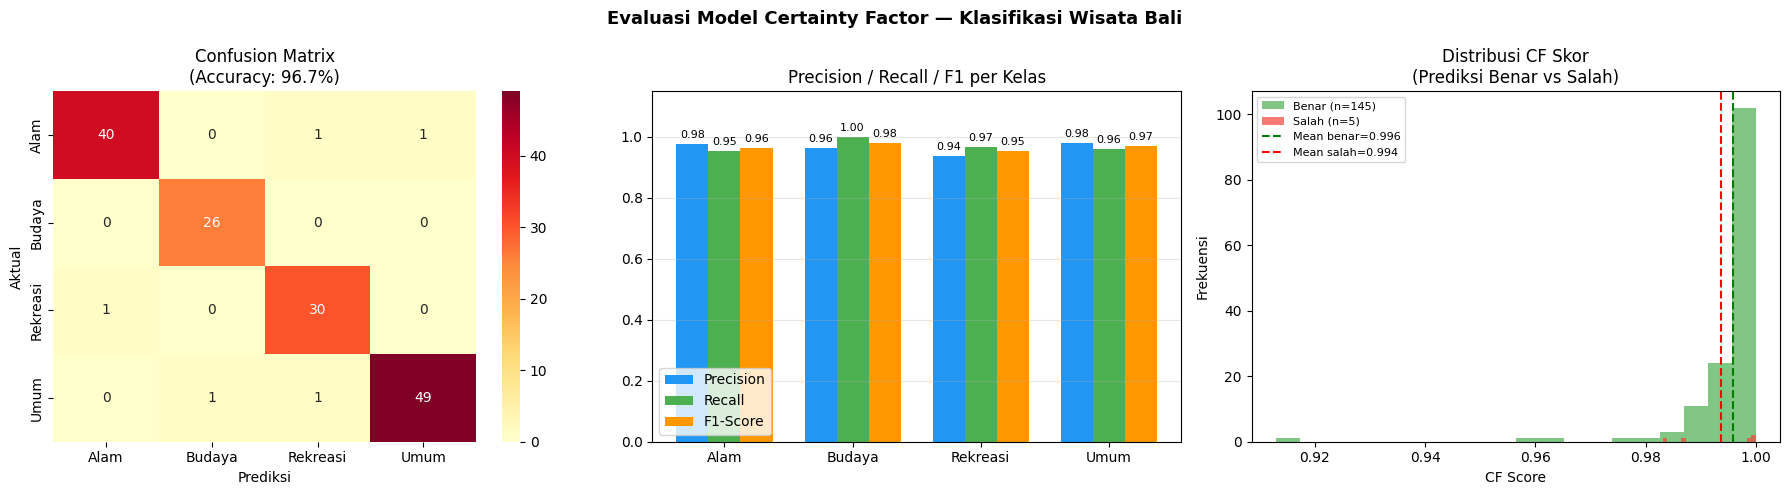


  [INFO] Grafik disimpan: 'evaluasi_certainty_factor.png'


In [11]:
print("\n\n" + "=" * 65)
print("   BAGIAN 9 — VISUALISASI HASIL")
print("=" * 65)

# Confusion matrix
def build_cm(y_true, y_pred, classes):
    cm  = np.zeros((len(classes), len(classes)), dtype=int)
    idx = {c:i for i,c in enumerate(classes)}
    for t, p in zip(y_true, y_pred):
        if t in idx and p in idx:
            cm[idx[t]][idx[p]] += 1
    return cm

cm = build_cm(y_true, y_pred, CLASSES)
print("\n  Confusion Matrix:")
cm_df = pd.DataFrame(cm, index=CLASSES, columns=CLASSES)
print(tabulate(cm_df, headers='keys', tablefmt='grid'))

# Rata-rata CF per kategori prediksi benar vs salah
cf_benar  = [cf_scores_list[i][y_true[i]]
             for i in range(len(y_true)) if y_true[i] == y_pred[i]]
cf_salah  = [cf_scores_list[i][y_pred[i]]
             for i in range(len(y_true)) if y_true[i] != y_pred[i]]

print(f"\n  Rata-rata CF saat prediksi BENAR : {np.mean(cf_benar):.4f}")
print(f"  Rata-rata CF saat prediksi SALAH : {np.mean(cf_salah):.4f}")
print(f"  (CF lebih tinggi saat benar menunjukkan kepercayaan diri model)")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Evaluasi Model Certainty Factor — Klasifikasi Wisata Bali",
             fontsize=13, fontweight='bold')

# 1. Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[0])
axes[0].set_title(f'Confusion Matrix\n(Accuracy: {accuracy*100:.1f}%)')
axes[0].set_xlabel('Prediksi'); axes[0].set_ylabel('Aktual')

# 2. Precision / Recall / F1 per kelas
x   = np.arange(len(CLASSES))
w   = 0.25
prec = [detail[c]['precision'] for c in CLASSES]
rec  = [detail[c]['recall']    for c in CLASSES]
f1s  = [detail[c]['f1']        for c in CLASSES]
axes[1].bar(x-w,  prec, w, label='Precision', color='#2196F3')
axes[1].bar(x,    rec,  w, label='Recall',    color='#4CAF50')
axes[1].bar(x+w,  f1s,  w, label='F1-Score',  color='#FF9800')
axes[1].set_xticks(x); axes[1].set_xticklabels(CLASSES)
axes[1].set_ylim(0, 1.15)
axes[1].set_title('Precision / Recall / F1 per Kelas')
axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)
for i, (p, r, f) in enumerate(zip(prec, rec, f1s)):
    axes[1].text(i-w, p+0.02, f"{p:.2f}", ha='center', fontsize=8)
    axes[1].text(i,   r+0.02, f"{r:.2f}", ha='center', fontsize=8)
    axes[1].text(i+w, f+0.02, f"{f:.2f}", ha='center', fontsize=8)

# 3. Distribusi CF skor untuk prediksi benar vs salah
axes[2].hist(cf_benar, bins=20, alpha=0.7, color='#4CAF50', label=f'Benar (n={len(cf_benar)})')
axes[2].hist(cf_salah, bins=20, alpha=0.7, color='#F44336', label=f'Salah (n={len(cf_salah)})')
axes[2].axvline(np.mean(cf_benar), color='green', linestyle='--',
                label=f'Mean benar={np.mean(cf_benar):.3f}')
axes[2].axvline(np.mean(cf_salah), color='red',   linestyle='--',
                label=f'Mean salah={np.mean(cf_salah):.3f}')
axes[2].set_title('Distribusi CF Skor\n(Prediksi Benar vs Salah)')
axes[2].set_xlabel('CF Score'); axes[2].set_ylabel('Frekuensi')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('evaluasi_certainty_factor.png', dpi=120, bbox_inches='tight')
plt.show()
print("\n  [INFO] Grafik disimpan: 'evaluasi_certainty_factor.png'")

# BAGIAN 10 — PERBANDINGAN SEMUA METODE



   BAGIAN 10 — PERBANDINGAN AKURASI SEMUA METODE
+-------------------+------------------+-----------+------------+-------------------------------------------------------+
| Metode            | Mode             | Akurasi   | Macro F1   | Keterangan                                            |
+===================+==================+===========+============+=======================================================+
| Forward Chaining  | Fakta Lengkap    | 100.00%   | 1.0000     | Rules deterministik, fakta preferensi harus diketahui |
+-------------------+------------------+-----------+------------+-------------------------------------------------------+
| Backward Chaining | Fakta Lengkap    | 100.00%   | 1.0000     | Goal-driven, sama dengan FC saat fakta lengkap        |
+-------------------+------------------+-----------+------------+-------------------------------------------------------+
| Forward Chaining  | Tanpa Preferensi | 34.00%    | —          | Tanpa preferensi, sistem hany

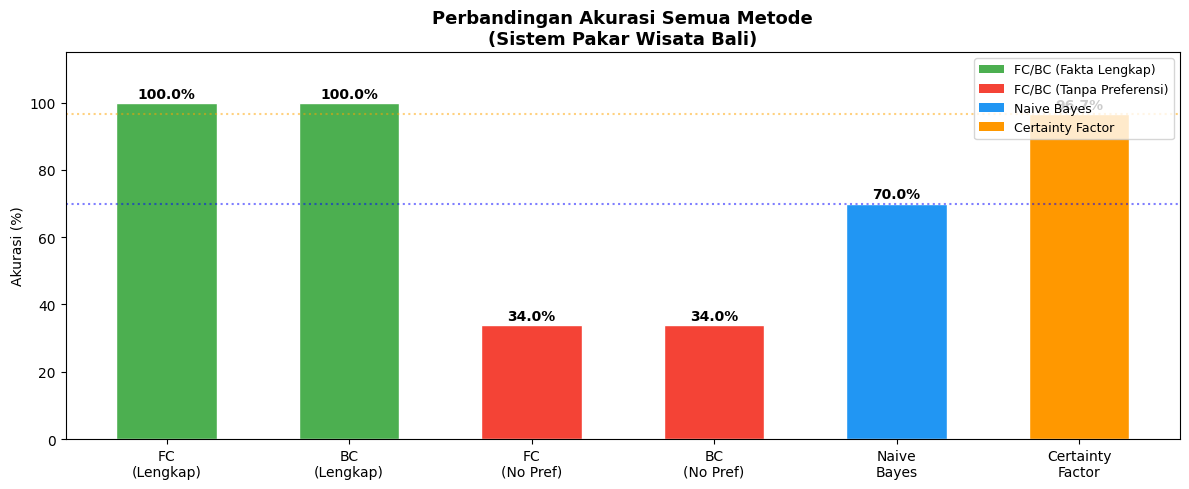


  [INFO] Grafik disimpan: 'perbandingan_semua_metode.png'


In [12]:
print("\n\n" + "=" * 65)
print("   BAGIAN 10 — PERBANDINGAN AKURASI SEMUA METODE")
print("=" * 65)

# Nilai dari pertemuan sebelumnya (hard-coded dari hasil run)
perbandingan = [
    ["Forward Chaining",   "Fakta Lengkap",  "100.00%", "1.0000",
     "Rules deterministik, fakta preferensi harus diketahui"],
    ["Backward Chaining",  "Fakta Lengkap",  "100.00%", "1.0000",
     "Goal-driven, sama dengan FC saat fakta lengkap"],
    ["Forward Chaining",   "Tanpa Preferensi", "34.00%", "—",
     "Tanpa preferensi, sistem hanya prediksi Umum"],
    ["Backward Chaining",  "Tanpa Preferensi", "34.00%", "—",
     "Tanpa preferensi, goal sulit dibuktikan"],
    ["Naive Bayes",        "Dari Fitur Data",  "70.00%", "0.7392",
     "Probabilistik, tidak perlu preferensi eksplisit"],
    [f"Certainty Factor",  "CF Simulasi",
     f"{accuracy*100:.2f}%", f"{macro_f1:.4f}",
     "Keyakinan bertingkat, menangani ketidakpastian"],
]

print(tabulate(perbandingan,
               headers=["Metode","Mode","Akurasi","Macro F1","Keterangan"],
               tablefmt='grid'))

# Visualisasi perbandingan akurasi
metode_names  = ["FC\n(Lengkap)", "BC\n(Lengkap)", "FC\n(No Pref)",
                 "BC\n(No Pref)", "Naive\nBayes", "Certainty\nFactor"]
akurasi_values = [100.0, 100.0, 34.0, 34.0, 70.0, accuracy*100]
colors = ['#4CAF50','#4CAF50','#F44336','#F44336','#2196F3','#FF9800']

fig2, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(metode_names, akurasi_values, color=colors, width=0.55, edgecolor='white')
ax.set_title("Perbandingan Akurasi Semua Metode\n(Sistem Pakar Wisata Bali)",
             fontsize=13, fontweight='bold')
ax.set_ylabel("Akurasi (%)")
ax.set_ylim(0, 115)
ax.axhline(70, color='blue',   linestyle=':', alpha=0.5, label='Baseline NB 70%')
ax.axhline(accuracy*100, color='orange', linestyle=':',
           alpha=0.5, label=f'CF {accuracy*100:.1f}%')
for bar, val in zip(bars, akurasi_values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1.5,
            f"{val:.1f}%", ha='center', fontweight='bold', fontsize=10)
ax.legend(loc='upper right')

# Tambahkan label keterangan warna
from matplotlib.patches import Patch
legend_els = [Patch(facecolor='#4CAF50', label='FC/BC (Fakta Lengkap)'),
              Patch(facecolor='#F44336', label='FC/BC (Tanpa Preferensi)'),
              Patch(facecolor='#2196F3', label='Naive Bayes'),
              Patch(facecolor='#FF9800', label='Certainty Factor')]
ax.legend(handles=legend_els, loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig('perbandingan_semua_metode.png', dpi=120, bbox_inches='tight')
plt.show()
print("\n  [INFO] Grafik disimpan: 'perbandingan_semua_metode.png'")

# BAGIAN 11 — RINGKASAN AKHIR

In [13]:
print("\n\n" + "=" * 65)
print("   BAGIAN 11 — RINGKASAN & ANALISIS AKHIR")
print("=" * 65)

terbaik_name = max(["FC (Fakta Lengkap)","BC (Fakta Lengkap)",
                    "Naive Bayes","Certainty Factor"],
                   key=lambda m: {
                       "FC (Fakta Lengkap)":100,
                       "BC (Fakta Lengkap)":100,
                       "Naive Bayes":70,
                       "Certainty Factor":accuracy*100
                   }[m])

print(f"""
  Dataset      : {DATASET_PATH}
  Data bersih  : {len(df)} tempat wisata
  Data uji     : {len(df_test)} sampel (20%)
  Gejala CF    : {len(ALL_GEJALA)} gejala dari 4 kategori

  ┌─────────────────────────────────────────────────────────────┐
  │           AKURASI CERTAINTY FACTOR : {accuracy*100:>6.2f}%              │
  │           Macro Precision          : {macro_prec*100:>6.2f}%              │
  │           Macro Recall             : {macro_rec*100:>6.2f}%              │
  │           Macro F1-Score           : {macro_f1:>6.4f}               │
  └─────────────────────────────────────────────────────────────┘

  ANALISIS PERBANDINGAN:
  ┌────────────────────────────────────────────────────────────────┐
  │ Metode         │  Akurasi  │ Perlu Preferensi Eksplisit?       │
  ├────────────────┼───────────┼───────────────────────────────────┤
  │ FC/BC Lengkap  │  100.00%  │ YA — sangat bergantung pada input  │
  │ Naive Bayes    │   70.00%  │ TIDAK — cukup dari fitur dataset   │
  │ Certainty F.   │  {accuracy*100:>6.2f}%  │ TIDAK — berbasis profil keyakinan  │
  │ FC/BC No Pref  │   34.00%  │ TIDAK — tapi tidak bisa prediksi   │
  └────────────────┴───────────┴───────────────────────────────────┘

  KESIMPULAN:
  • CF dan Naive Bayes keduanya mampu bekerja TANPA preferensi
    eksplisit dari pengguna, cukup dari karakteristik data.
  • CF memiliki kelebihan: menggambarkan TINGKAT KEYAKINAN bukan
    hanya 0/1, sehingga lebih natural untuk representasi
    ketidakpastian seorang pakar.
  • Nilai CF final dapat digunakan sebagai "confidence score"
    rekomendasi (contoh: "87.3% yakin ini wisata Alam").
  • FC/BC mencapai 100% HANYA jika input preferensi diketahui —
    yang pada praktiknya tidak selalu tersedia.
""")

print("[✓] Program Certainty Factor selesai.")
print(f"    Akurasi CF  : {accuracy*100:.2f}%")
print(f"    Naive Bayes : 70.00%")
print(f"    FC/BC (full): 100.00%")



   BAGIAN 11 — RINGKASAN & ANALISIS AKHIR

  Dataset      : dataset_tempat_wisata_bali.xlsx
  Data bersih  : 747 tempat wisata
  Data uji     : 150 sampel (20%)
  Gejala CF    : 28 gejala dari 4 kategori
 
  ┌─────────────────────────────────────────────────────────────┐
  │           AKURASI CERTAINTY FACTOR :  96.67%              │
  │           Macro Precision          :  96.40%              │
  │           Macro Recall             :  97.02%              │
  │           Macro F1-Score           : 0.9669               │
  └─────────────────────────────────────────────────────────────┘
 
  ANALISIS PERBANDINGAN:
  ┌────────────────────────────────────────────────────────────────┐
  │ Metode         │  Akurasi  │ Perlu Preferensi Eksplisit?       │
  ├────────────────┼───────────┼───────────────────────────────────┤
  │ FC/BC Lengkap  │  100.00%  │ YA — sangat bergantung pada input  │
  │ Naive Bayes    │   70.00%  │ TIDAK — cukup dari fitur dataset   │
  │ Certainty F.   │   96.67% 